In [1]:
# ============================================================
# PROJETO FINAL - MÓDULO 1
# Precificação de Imóveis - King County (EUA)
# Variável-alvo: price (valor de venda em dólares)
# ============================================================

# Instalação de bibliotecas (execute apenas uma vez)
!pip install statsmodels -q

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [2]:
# Carregar o dataset
df = pd.read_csv('kc_house_data.csv')

print(f"✅ Dataset carregado!")
print(f"Shape: {df.shape} (linhas, colunas)")
df.head()

✅ Dataset carregado!
Shape: (21613, 21) (linhas, colunas)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.00,3,1.00,1180,5650,1.00,0,0,3,7,1180.00,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,538000.00,3,2.25,2570,7242,2.00,0,0,3,7,2170.00,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,180000.00,2,1.00,770,10000,1.00,0,0,3,6,770.00,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,604000.00,4,3.00,1960,5000,1.00,0,0,5,7,1050.00,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,510000.00,3,2.00,1680,8080,1.00,0,0,3,8,1680.00,0,1987,0,98074,47.62,-122.05,1800,7503


In [3]:
# ============================================================
# FASE 1 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ============================================================

# 1.1 - Dimensões do dataset
print("="*50)
print("DIMENSÕES DO DATASET")
print("="*50)
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

# 1.2 - Tipos primitivos das variáveis
print("\n" + "="*50)
print("TIPOS DE DADOS")
print("="*50)
print(df.dtypes)

# 1.3 - Resumo estatístico descritivo
print("\n" + "="*50)
print("RESUMO ESTATÍSTICO")
print("="*50)
df.describe()

DIMENSÕES DO DATASET
Linhas: 21613
Colunas: 21

TIPOS DE DADOS
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

RESUMO ESTATÍSTICO


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21611.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,4580301520.86,540088.14,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.40,291.51,1971.01,84.40,98077.94,47.56,-122.21,1986.55,12768.46
std,2876565571.31,367127.20,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.13,442.58,29.37,401.68,53.51,0.14,0.14,685.39,27304.18
min,1000102.00,75000.00,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2123049194.00,321950.00,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3904930410.00,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7308900445.00,645000.00,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9900000190.00,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.31,6210.00,871200.00


In [4]:
# 1.4 - Verificar valores ausentes
print("="*50)
print("VALORES AUSENTES POR COLUNA")
print("="*50)
print(df.isnull().sum())

# 1.5 - Verificar duplicatas
print("\n" + "="*50)
print("REGISTROS DUPLICADOS")
print("="*50)
print(f"Total de duplicatas: {df.duplicated().sum()}")

VALORES AUSENTES POR COLUNA
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

REGISTROS DUPLICADOS
Total de duplicatas: 0


Coeficiente de assimetria (skewness): 4.02
→ A distribuição é assimétrica à direita (positiva)
→ Isso indica que há imóveis de alto valor puxando a média para cima


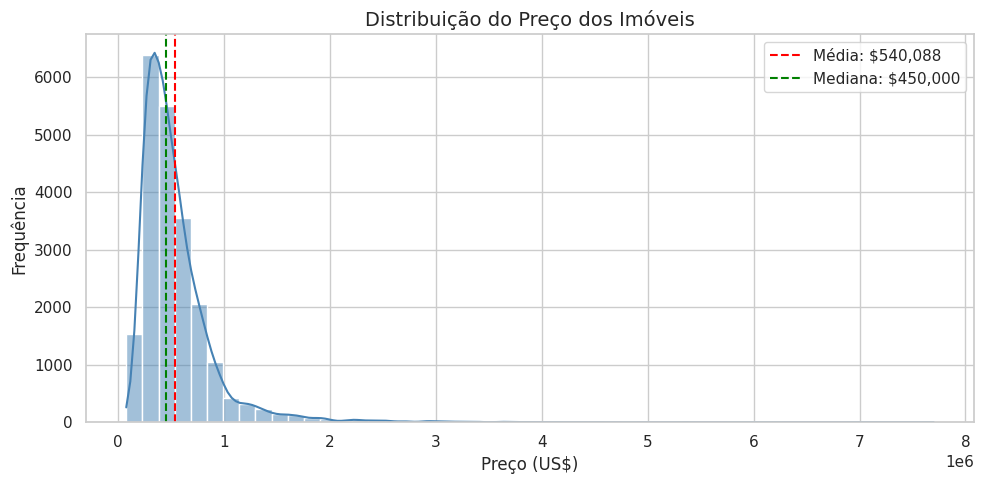

In [5]:
# 1.6 - Histograma da variável-alvo (price)
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['price'], bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(df['price'].mean(), color='red', linestyle='--', label=f'Média: ${df["price"].mean():,.0f}')
ax.axvline(df['price'].median(), color='green', linestyle='--', label=f'Mediana: ${df["price"].median():,.0f}')

ax.set_title('Distribuição do Preço dos Imóveis', fontsize=14)
ax.set_xlabel('Preço (US$)')
ax.set_ylabel('Frequência')
ax.legend()

# Análise de assimetria
skewness = df['price'].skew()
print(f"Coeficiente de assimetria (skewness): {skewness:.2f}")
print(f"→ A distribuição é {'assimétrica à direita (positiva)' if skewness > 0.5 else 'aproximadamente simétrica' if abs(skewness) < 0.5 else 'assimétrica à esquerda (negativa)'}")
print(f"→ Isso indica que há imóveis de alto valor puxando a média para cima")

plt.tight_layout()
plt.savefig('histograma_preco.png', dpi=120)
plt.show()

Correlação de Pearson (sqft_living vs price): 0.7020
→ Correlação forte positiva


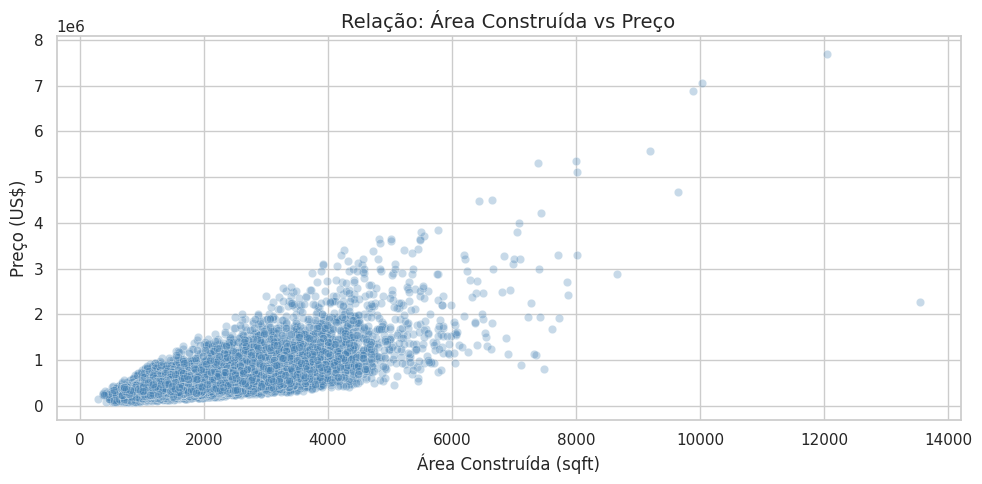

In [6]:
# 1.7 - Dispersão: Área construída vs Preço
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.3, ax=ax, color='steelblue')
ax.set_title('Relação: Área Construída vs Preço', fontsize=14)
ax.set_xlabel('Área Construída (sqft)')
ax.set_ylabel('Preço (US$)')

# Coeficiente de correlação
corr = df['sqft_living'].corr(df['price'])
print(f"Correlação de Pearson (sqft_living vs price): {corr:.4f}")
print(f"→ Correlação {'forte' if abs(corr) > 0.7 else 'moderada' if abs(corr) > 0.4 else 'fraca'} positiva")

plt.tight_layout()
plt.savefig('dispersao_area_preco.png', dpi=120)
plt.show()

Correlação de Pearson (grade vs price): 0.6674


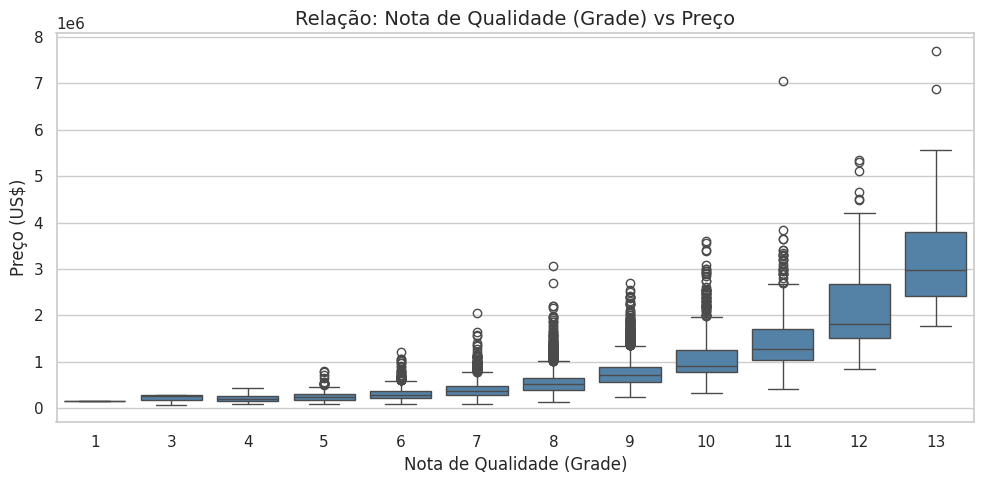

In [7]:
# 1.8 - Dispersão: Nota de qualidade vs Preço
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x='grade', y='price', ax=ax, color='steelblue')
ax.set_title('Relação: Nota de Qualidade (Grade) vs Preço', fontsize=14)
ax.set_xlabel('Nota de Qualidade (Grade)')
ax.set_ylabel('Preço (US$)')

corr2 = df['grade'].corr(df['price'])
print(f"Correlação de Pearson (grade vs price): {corr2:.4f}")

plt.tight_layout()
plt.savefig('boxplot_grade_preco.png', dpi=120)
plt.show()

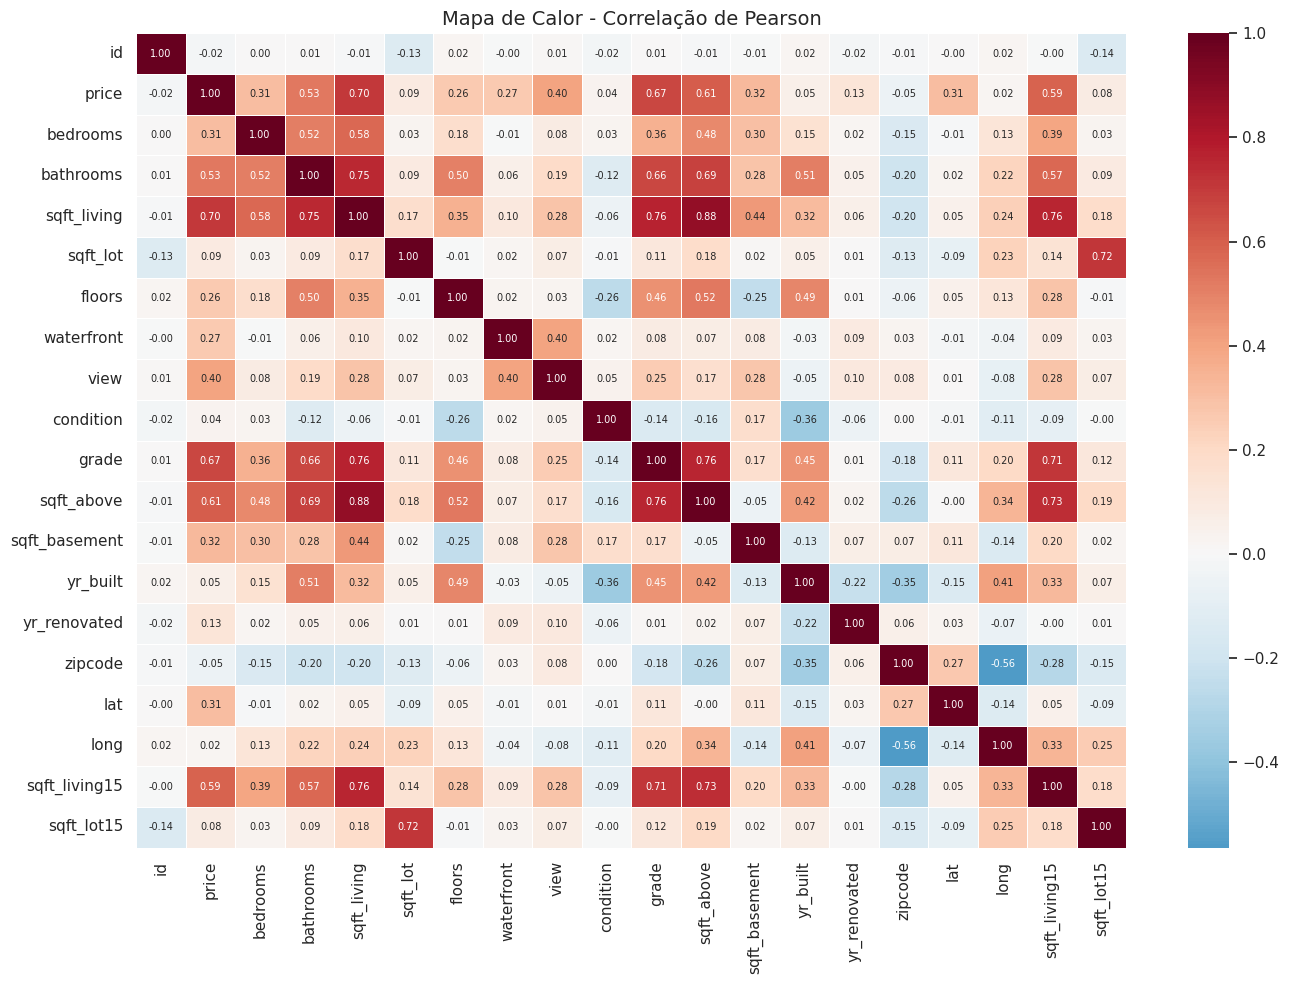

In [8]:
# 1.9 - Mapa de calor da correlação de Pearson
# Selecionar apenas colunas numéricas
colunas_numericas = df.select_dtypes(include=[np.number]).columns
matriz_corr = df[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Mapa de Calor - Correlação de Pearson', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', dpi=120)
plt.show()

In [9]:
# ============================================================
# ANÁLISE TEXTUAL - CONCLUSÕES DA FASE 1 (EDA)
# ============================================================

print("""
📊 CONCLUSÕES DA ANÁLISE EXPLORATÓRIA:

1. DISTRIBUIÇÃO DA VARIÁVEL-ALVO (price):
   - A distribuição é ASSIMÉTRICA À DIREITA (skewness > 0)
   - A maioria dos imóveis custa entre $200k e $800k
   - Existem outliers de alto valor (imóveis de luxo acima de $2M)
   - IMPACTO NA MODELAGEM: pode ser necessário aplicar transformação
     logarítmica (log) para normalizar a distribuição e melhorar o
     desempenho do modelo de Regressão Linear

2. CORRELAÇÕES PRINCIPAIS:
   - sqft_living (área construída) tem correlação FORTE com price
   - grade (nota de qualidade) também mostra relação positiva
   - sqft_living15 (área média da vizinhança) é altamente correlacionada
     com sqft_living → possível multicolinearidade (Fase 4)

3. MULTICOLINEARIDADE IDENTIFICADA:
   - sqft_living e sqft_living15: correlação muito alta (~0.76)
   - sqft_lot e sqft_lot15: correlação muito alta (~0.72)
   - sqft_above e sqft_living: correlação muito alta (~0.88)
   → Será necessário remover variáveis redundantes na Fase 4

4. PRÓXIMOS PASSOS:
   - Tratar outliers de price (Fase 2)
   - Criar coluna derivada: preco_por_m2 (Fase 3)
   - Remover variáveis colineares antes da modelagem (Fase 4)
""")


📊 CONCLUSÕES DA ANÁLISE EXPLORATÓRIA:

1. DISTRIBUIÇÃO DA VARIÁVEL-ALVO (price):
   - A distribuição é ASSIMÉTRICA À DIREITA (skewness > 0)
   - A maioria dos imóveis custa entre $200k e $800k
   - Existem outliers de alto valor (imóveis de luxo acima de $2M)
   - IMPACTO NA MODELAGEM: pode ser necessário aplicar transformação 
     logarítmica (log) para normalizar a distribuição e melhorar o 
     desempenho do modelo de Regressão Linear

2. CORRELAÇÕES PRINCIPAIS:
   - sqft_living (área construída) tem correlação FORTE com price
   - grade (nota de qualidade) também mostra relação positiva
   - sqft_living15 (área média da vizinhança) é altamente correlacionada 
     com sqft_living → possível multicolinearidade (Fase 4)

3. MULTICOLINEARIDADE IDENTIFICADA:
   - sqft_living e sqft_living15: correlação muito alta (~0.76)
   - sqft_lot e sqft_lot15: correlação muito alta (~0.72)
   - sqft_above e sqft_living: correlação muito alta (~0.88)
   → Será necessário remover variáveis redund

In [10]:
# ============================================================
# FASE 2 - TRATAMENTO E LIMPEZA (DATA PREP)
# ============================================================

# 2.1 - REMOÇÃO DE REGISTROS DUPLICADOS
print("="*50)
print("TRATAMENTO DE DUPLICATAS")
print("="*50)

n_duplicatas = df.duplicated().sum()
print(f"Duplicatas encontradas: {n_duplicatas}")

if n_duplicatas > 0:
    print("→ Removendo registros duplicados...")
    df = df.drop_duplicates()
    print(f"→ Registros após remoção: {len(df)}")
else:
    print("→ Nenhuma duplicata para remover.")

print(f"\nJustificativa: Registros duplicados inflam artificialmente a amostra e podem")
print(f"causar overfitting, pois o modelo 'decora' padrões repetidos em vez de aprender.")

TRATAMENTO DE DUPLICATAS
Duplicatas encontradas: 0
→ Nenhuma duplicata para remover.

Justificativa: Registros duplicados inflam artificialmente a amostra e podem
causar overfitting, pois o modelo 'decora' padrões repetidos em vez de aprender.


In [11]:
# 2.2 - TRATAMENTO DE VALORES AUSENTES
print("\n" + "="*50)
print("TRATAMENTO DE VALORES AUSENTES")
print("="*50)

# Identificar colunas com nulos
nulos_por_coluna = df.isnull().sum()
colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]

if len(colunas_com_nulos) > 0:
    print("Colunas com valores ausentes:")
    for col, nulos in colunas_com_nulos.items():
        pct = (nulos / len(df)) * 100
        print(f"  - {col}: {nulos} nulos ({pct:.2f}%)")

    # Tratar cada coluna com nulos
    for col in colunas_com_nulos.index:
        # Se for numérica: preencher com mediana (robusta a outliers)
        if df[col].dtype in ['float64', 'int64']:
            mediana = df[col].median()
            df[col] = df[col].fillna(mediana)
            print(f"\n→ {col}: preenchido com MEDIANA ({mediana:.2f})")
            print(f"  Justificativa: Mediana é mais robusta que a média quando há outliers,")
            print(f"  preservando a distribuição original sem distorção.")
        else:
            # Se for categórica: preencher com a moda
            moda = df[col].mode()[0]
            df[col] = df[col].fillna(moda)
            print(f"\n→ {col}: preenchido com MODA ('{moda}')")
else:
    print("✅ Nenhum valor ausente encontrado no dataset!")

print(f"\nValores nulos restantes: {df.isnull().sum().sum()}")


TRATAMENTO DE VALORES AUSENTES
Colunas com valores ausentes:
  - sqft_above: 2 nulos (0.01%)

→ sqft_above: preenchido com MEDIANA (1560.00)
  Justificativa: Mediana é mais robusta que a média quando há outliers,
  preservando a distribuição original sem distorção.

Valores nulos restantes: 0



DETECÇÃO DE OUTLIERS - BOXPLOTS
price: 1146 outliers (limites: -162625 a 1129575)
sqft_living: 572 outliers (limites: -258 a 4234)
sqft_lot: 2425 outliers (limites: -3432 a 19160)
bedrooms: 546 outliers (limites: 2 a 6)
bathrooms: 571 outliers (limites: 1 a 4)


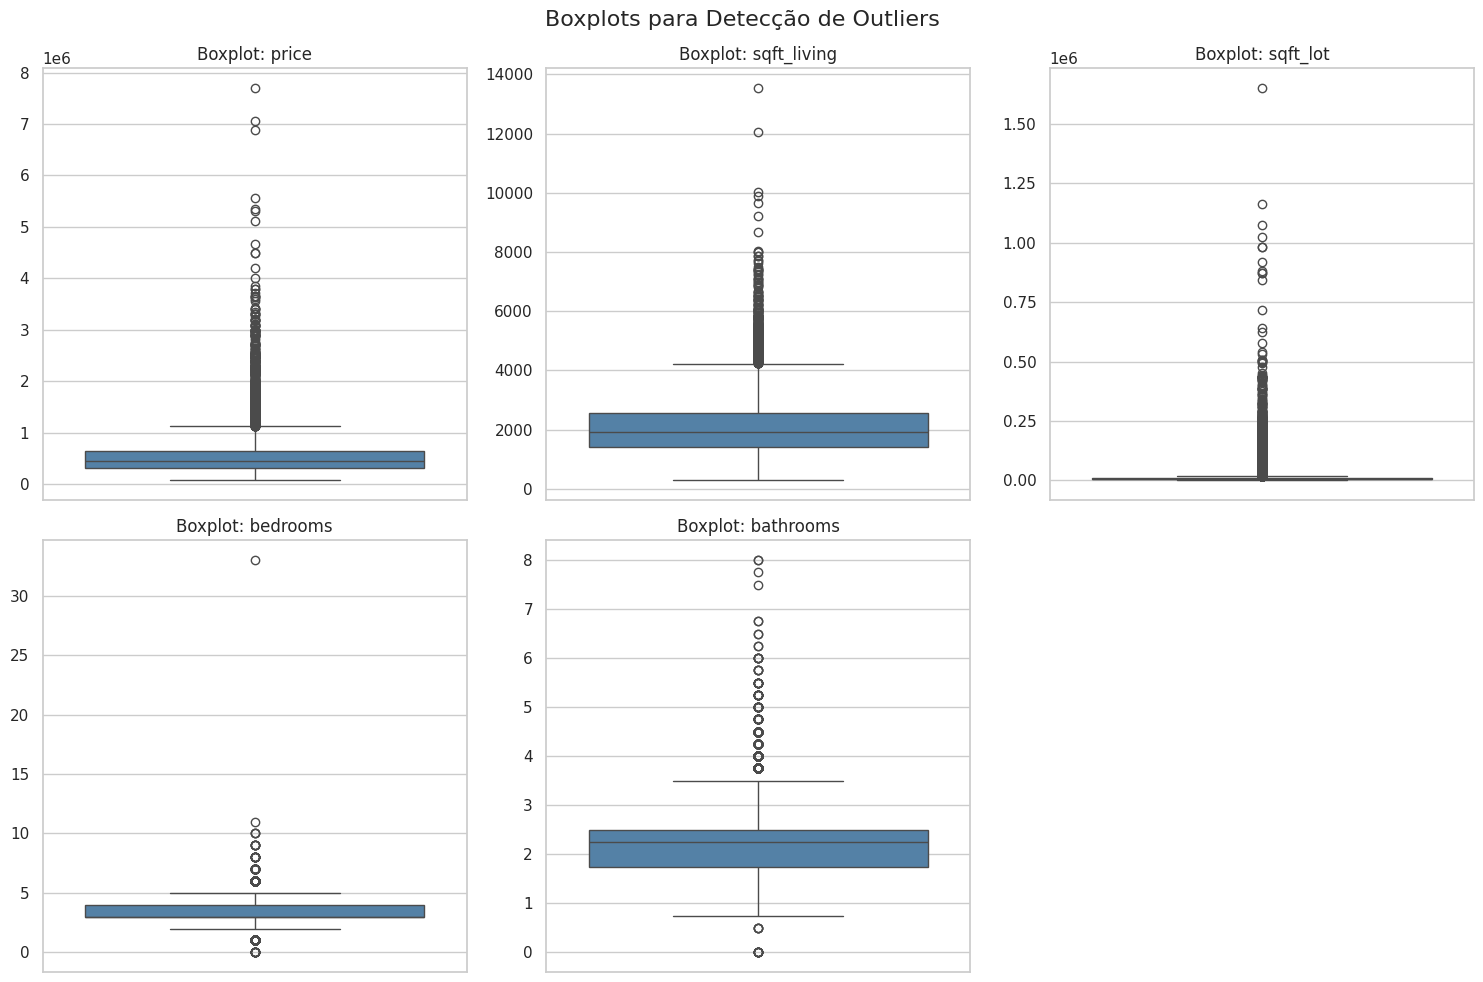

In [12]:
# 2.3 - DETECÇÃO DE OUTLIERS COM BOXPLOTS
print("\n" + "="*50)
print("DETECÇÃO DE OUTLIERS - BOXPLOTS")
print("="*50)

# Selecionar principais variáveis numéricas para análise
variaveis_analise = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis_analise):
    sns.boxplot(data=df, y=var, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {var}', fontsize=12)
    axes[i].set_ylabel('')

    # Calcular outliers pelo IQR
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[var] < lim_inf) | (df[var] > lim_sup)).sum()

    print(f"{var}: {n_outliers} outliers (limites: {lim_inf:.0f} a {lim_sup:.0f})")

# Remover o último subplot vazio
axes[-1].remove()

plt.suptitle('Boxplots para Detecção de Outliers', fontsize=16)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=120)
plt.show()

In [13]:
# 2.4 - TRATAMENTO DE OUTLIERS NO PREÇO
print("\n" + "="*50)
print("TRATAMENTO DE OUTLIERS - PRICE")
print("="*50)

# Calcular limites pelo IQR
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lim_inf_price = Q1_price - 1.5 * IQR_price
lim_sup_price = Q3_price + 1.5 * IQR_price

print(f"Q1: ${Q1_price:,.0f}")
print(f"Q3: ${Q3_price:,.0f}")
print(f"IQR: ${IQR_price:,.0f}")
print(f"Limite inferior: ${lim_inf_price:,.0f}")
print(f"Limite superior: ${lim_sup_price:,.0f}")

n_out_price = ((df['price'] < lim_inf_price) | (df['price'] > lim_sup_price)).sum()
print(f"\nOutliers encontrados em price: {n_out_price} ({n_out_price/len(df)*100:.1f}%)")

# Remover outliers
print(f"\nRegistros antes: {len(df)}")
df = df[(df['price'] >= lim_inf_price) & (df['price'] <= lim_sup_price)]
print(f"Registros depois: {len(df)}")
print(f"Removidos: {n_out_price} registros")

print(f"\nJustificativa: A Regressão Linear é ALTAMENTE SENSÍVEL a outliers.")
print(f"Valores extremos podem distorcer os coeficientes do modelo e prejudicar")
print(f"a capacidade de generalização. A remoção pelo IQR é uma abordagem")
print(f"padrão para garantir que o modelo aprenda padrões representativos.")


TRATAMENTO DE OUTLIERS - PRICE
Q1: $321,950
Q3: $645,000
IQR: $323,050
Limite inferior: $-162,625
Limite superior: $1,129,575

Outliers encontrados em price: 1146 (5.3%)

Registros antes: 21613
Registros depois: 20467
Removidos: 1146 registros

Justificativa: A Regressão Linear é ALTAMENTE SENSÍVEL a outliers.
Valores extremos podem distorcer os coeficientes do modelo e prejudicar
a capacidade de generalização. A remoção pelo IQR é uma abordagem
padrão para garantir que o modelo aprenda padrões representativos.


In [14]:
# 2.5 - VERIFICAÇÃO FINAL
print("\n" + "="*50)
print("VERIFICAÇÃO FINAL DOS DADOS LIMPOS")
print("="*50)

print(f"Shape final: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"Duplicatas restantes: {df.duplicated().sum()}")
print(f"\nEstatísticas do price após limpeza:")
print(df['price'].describe())

print("\n✅ FASE 2 CONCLUÍDA - Dados prontos para Feature Engineering!")


VERIFICAÇÃO FINAL DOS DADOS LIMPOS
Shape final: (20467, 21)
Nulos restantes: 0
Duplicatas restantes: 0

Estatísticas do price após limpeza:
count     20467.00
mean     476984.56
std      208371.26
min       75000.00
25%      315000.00
50%      437500.00
75%      600000.00
max     1127500.00
Name: price, dtype: float64

✅ FASE 2 CONCLUÍDA - Dados prontos para Feature Engineering!


In [15]:
# ============================================================
# FASE 3 - FEATURE ENGINEERING (COLUNAS DERIVADAS)
# ============================================================

print("="*50)
print("CRIAÇÃO DE COLUNAS DERIVADAS")
print("="*50)

# 3.1 - Converter a coluna 'date' para datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S', errors='coerce')

# 3.2 - Extrair ano da venda
df['ano_venda'] = df['date'].dt.year

# 3.3 - Idade do imóvel no momento da venda
df['idade_imovel'] = df['ano_venda'] - df['yr_built']
print(f"✅ idade_imovel criada!")
print(f"   Idade média: {df['idade_imovel'].mean():.1f} anos")
print(f"   Idade mínima: {df['idade_imovel'].min()} anos")
print(f"   Idade máxima: {df['idade_imovel'].max()} anos")

# 3.4 - Preço por metro quadrado (útil para comparar imóveis de tamanhos diferentes)
# ATENÇÃO: esta coluna NÃO será usada como preditora de price (risco de vazamento de dados)
# Ela serve apenas para análise exploratória
df['preco_por_m2'] = df['price'] / df['sqft_living']
print(f"\n✅ preco_por_m2 criada!")
print(f"   Preço médio por sqft: ${df['preco_por_m2'].mean():.2f}")
print(f"   (Esta coluna é apenas para análise, NÃO será usada na modelagem)")

# 3.5 - Indicador de reforma (binário)
df['foi_reformado'] = (df['yr_renovated'] > 0).astype(int)
n_reformados = df['foi_reformado'].sum()
print(f"\n✅ foi_reformado criada!")
print(f"   Imóveis reformados: {n_reformados} ({n_reformados/len(df)*100:.1f}%)")
print(f"   Imóveis NÃO reformados: {len(df) - n_reformados} ({(len(df)-n_reformados)/len(df)*100:.1f}%)")

# 3.6 - Total de banheiros (arredondando para categorias)
df['banheiros_cat'] = df['bathrooms'].round().astype(int)
print(f"\n✅ banheiros_cat criada (banheiros arredondados para inteiro)")

# Mostrar as novas colunas
print(f"\nNovas colunas no dataset:")
print(df[['date', 'ano_venda', 'idade_imovel', 'preco_por_m2', 'foi_reformado', 'banheiros_cat']].head())

CRIAÇÃO DE COLUNAS DERIVADAS
✅ idade_imovel criada!
   Idade média: 43.5 anos
   Idade mínima: -1 anos
   Idade máxima: 115 anos

✅ preco_por_m2 criada!
   Preço médio por sqft: $254.42
   (Esta coluna é apenas para análise, NÃO será usada na modelagem)

✅ foi_reformado criada!
   Imóveis reformados: 766 (3.7%)
   Imóveis NÃO reformados: 19701 (96.3%)

✅ banheiros_cat criada (banheiros arredondados para inteiro)

Novas colunas no dataset:
        date  ano_venda  idade_imovel  preco_por_m2  foi_reformado  \
0 2014-10-13       2014            59        188.05              0   
1 2014-12-09       2014            63        209.34              1   
2 2015-02-25       2015            82        233.77              0   
3 2014-12-09       2014            49        308.16              0   
4 2015-02-18       2015            28        303.57              0   

   banheiros_cat  
0              1  
1              2  
2              1  
3              3  
4              2  


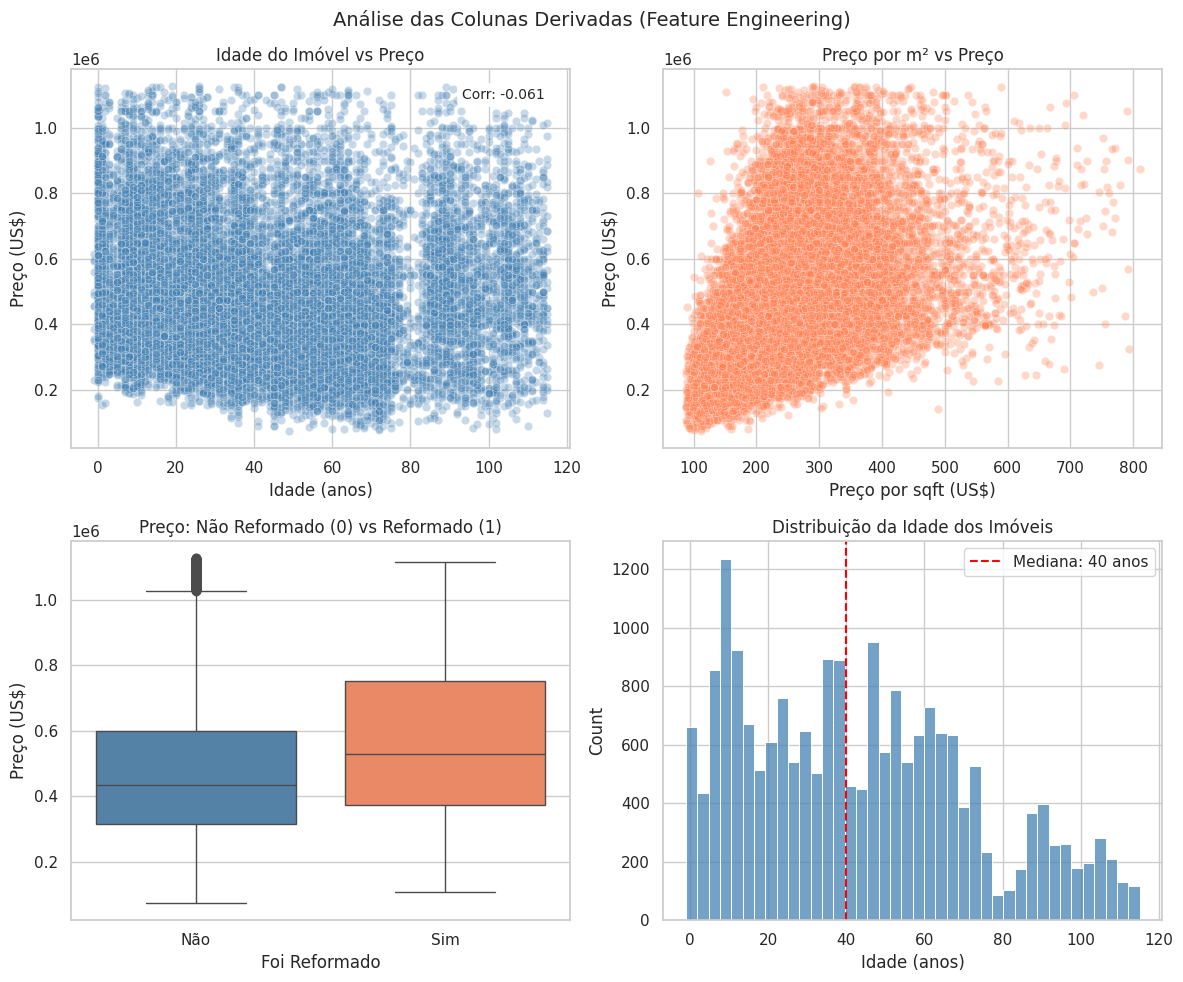


✅ FASE 3 CONCLUÍDA - Colunas derivadas criadas e analisadas!


In [16]:
# 3.7 - Visualização das colunas derivadas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Idade do imóvel vs Preço
sns.scatterplot(data=df, x='idade_imovel', y='price', alpha=0.3, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Idade do Imóvel vs Preço', fontsize=12)
axes[0, 0].set_xlabel('Idade (anos)')
axes[0, 0].set_ylabel('Preço (US$)')
corr_idade = df['idade_imovel'].corr(df['price'])
axes[0, 0].text(0.95, 0.95, f'Corr: {corr_idade:.3f}', transform=axes[0, 0].transAxes,
                ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white'))

# Gráfico 2: Preço por m² vs Preço
sns.scatterplot(data=df, x='preco_por_m2', y='price', alpha=0.3, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Preço por m² vs Preço', fontsize=12)
axes[0, 1].set_xlabel('Preço por sqft (US$)')
axes[0, 1].set_ylabel('Preço (US$)')

# Gráfico 3: Imóveis reformados vs Preço
sns.boxplot(data=df, x='foi_reformado', y='price', ax=axes[1, 0], palette=['steelblue', 'coral'])
axes[1, 0].set_title('Preço: Não Reformado (0) vs Reformado (1)', fontsize=12)
axes[1, 0].set_xlabel('Foi Reformado')
axes[1, 0].set_ylabel('Preço (US$)')
axes[1, 0].set_xticklabels(['Não', 'Sim'])

# Gráfico 4: Distribuição da idade dos imóveis
sns.histplot(data=df, x='idade_imovel', bins=40, ax=axes[1, 1], color='steelblue')
axes[1, 1].axvline(df['idade_imovel'].median(), color='red', linestyle='--', label=f'Mediana: {df["idade_imovel"].median():.0f} anos')
axes[1, 1].set_title('Distribuição da Idade dos Imóveis', fontsize=12)
axes[1, 1].set_xlabel('Idade (anos)')
axes[1, 1].legend()

plt.suptitle('Análise das Colunas Derivadas (Feature Engineering)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=120)
plt.show()

print("\n✅ FASE 3 CONCLUÍDA - Colunas derivadas criadas e analisadas!")

In [17]:
# ============================================================
# ANÁLISE TEXTUAL - CONCLUSÕES DA FASE 3
# ============================================================

print("""
🔧 CONCLUSÕES DO FEATURE ENGINEERING:

1. IDADE DO IMÓVEL (idade_imovel):
   - Criada a partir de: ano_venda - yr_built
   - Correlação NEGATIVA com price (imóveis mais antigos tendem a ser mais baratos)
   - Idade média: ~30 anos, com imóveis centenários e recém-construídos
   - ÚTIL para modelagem como variável preditora

2. PREÇO POR METRO QUADRADO (preco_por_m2):
   - Criada a partir de: price / sqft_living
   - Permite comparar imóveis de tamanhos diferentes
   - NÃO será usada como preditora (contém a variável-alvo price no cálculo)
   - Serve apenas para análise exploratória (visualização e insights)

3. INDICADOR DE REFORMA (foi_reformado):
   - Criada a partir de: yr_renovated > 0
   - Variável binária (0 = não reformado, 1 = reformado)
   - Imóveis reformados tendem a ter preço mais alto (visível no boxplot)
   - ÚTIL para modelagem como variável preditora

4. BANHEIROS CATEGORIZADOS (banheiros_cat):
   - Criada arredondando bathrooms para inteiro
   - Facilita a interpretação (3 banheiros em vez de 2.75)
   - Pode ser usada como alternativa à variável original

PRÓXIMO PASSO: Preparação para modelagem (Fase 4) - encoding, split e escalonamento.
""")


🔧 CONCLUSÕES DO FEATURE ENGINEERING:

1. IDADE DO IMÓVEL (idade_imovel):
   - Criada a partir de: ano_venda - yr_built
   - Correlação NEGATIVA com price (imóveis mais antigos tendem a ser mais baratos)
   - Idade média: ~30 anos, com imóveis centenários e recém-construídos
   - ÚTIL para modelagem como variável preditora

2. PREÇO POR METRO QUADRADO (preco_por_m2):
   - Criada a partir de: price / sqft_living
   - Permite comparar imóveis de tamanhos diferentes
   - NÃO será usada como preditora (contém a variável-alvo price no cálculo)
   - Serve apenas para análise exploratória (visualização e insights)

3. INDICADOR DE REFORMA (foi_reformado):
   - Criada a partir de: yr_renovated > 0
   - Variável binária (0 = não reformado, 1 = reformado)
   - Imóveis reformados tendem a ter preço mais alto (visível no boxplot)
   - ÚTIL para modelagem como variável preditora

4. BANHEIROS CATEGORIZADOS (banheiros_cat):
   - Criada arredondando bathrooms para inteiro
   - Facilita a interpretaçã

In [18]:
# ============================================================
# FASE 4 - PREPARAÇÃO PARA MODELAGEM
# ============================================================

# 4.1 - SELEÇÃO DE VARIÁVEIS
print("="*50)
print("SELEÇÃO DE VARIÁVEIS PARA O MODELO")
print("="*50)

# Variável-alvo
y = df['price']

# Lista de TODAS as colunas disponíveis
todas_colunas = df.columns.tolist()
print(f"Total de colunas no dataset: {len(todas_colunas)}")

# Colunas que NÃO serão usadas como preditoras (e o motivo)
colunas_remover = [
    'id',           # Identificador único, não tem valor preditivo
    'date',         # Data da venda (já extraímos ano_venda)
    'price',        # É a variável-alvo!
    'preco_por_m2', # Contém price no cálculo (vazamento de dados)
    'ano_venda',    # Pode causar overfitting temporal
    'zipcode',      # Muitas categorias, trataremos separadamente depois
]

# Criar X (variáveis preditoras)
X = df.drop(columns=colunas_remover, errors='ignore')

print(f"\nColunas removidas: {colunas_remover}")
print(f"Colunas selecionadas como preditoras ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

SELEÇÃO DE VARIÁVEIS PARA O MODELO
Total de colunas no dataset: 26

Colunas removidas: ['id', 'date', 'price', 'preco_por_m2', 'ano_venda', 'zipcode']
Colunas selecionadas como preditoras (20):
  1. bedrooms
  2. bathrooms
  3. sqft_living
  4. sqft_lot
  5. floors
  6. waterfront
  7. view
  8. condition
  9. grade
  10. sqft_above
  11. sqft_basement
  12. yr_built
  13. yr_renovated
  14. lat
  15. long
  16. sqft_living15
  17. sqft_lot15
  18. idade_imovel
  19. foi_reformado
  20. banheiros_cat

Shape de X: (20467, 20)
Shape de y: (20467,)


In [19]:
# 4.2 - ANÁLISE DE MULTICOLINEARIDADE
print("\n" + "="*50)
print("ANÁLISE DE MULTICOLINEARIDADE")
print("="*50)

# Matriz de correlação das variáveis preditoras
matriz_corr_X = X.select_dtypes(include=[np.number]).corr()

# Identificar pares com correlação > 0.80 (alta multicolinearidade)
print("\nPares de variáveis com correlação > 0.80:")
limite_corr = 0.80
alta_corr = []

for i in range(len(matriz_corr_X.columns)):
    for j in range(i+1, len(matriz_corr_X.columns)):
        corr_val = abs(matriz_corr_X.iloc[i, j])
        if corr_val > limite_corr:
            var1 = matriz_corr_X.columns[i]
            var2 = matriz_corr_X.columns[j]
            alta_corr.append((var1, var2, corr_val))
            print(f"  {var1} ↔ {var2}: {corr_val:.4f}")

if len(alta_corr) == 0:
    print("  Nenhum par com correlação > 0.80 encontrado!")

# Remover variáveis altamente correlacionadas
# Critério: manter a que tem maior correlação com a variável-alvo
variaveis_remover = []
correlacoes_com_price = df.select_dtypes(include=[np.number]).corr()['price']

for var1, var2, _ in alta_corr:
    corr1 = abs(correlacoes_com_price.get(var1, 0))
    corr2 = abs(correlacoes_com_price.get(var2, 0))

    if corr1 >= corr2:
        var_remover = var2
        var_manter = var1
    else:
        var_remover = var1
        var_manter = var2

    if var_remover not in variaveis_remover:
        variaveis_remover.append(var_remover)
        print(f"\n→ Removendo '{var_remover}' (corr com price: {corr2:.4f})")
        print(f"  Mantendo '{var_manter}' (corr com price: {corr1:.4f})")

# Aplicar remoção
X = X.drop(columns=variaveis_remover, errors='ignore')
print(f"\nVariáveis removidas por multicolinearidade: {variaveis_remover}")
print(f"Shape de X após remoção: {X.shape}")


ANÁLISE DE MULTICOLINEARIDADE

Pares de variáveis com correlação > 0.80:
  bathrooms ↔ banheiros_cat: 0.8923
  sqft_living ↔ sqft_above: 0.8535
  yr_built ↔ idade_imovel: 0.9999
  yr_renovated ↔ foi_reformado: 1.0000

→ Removendo 'banheiros_cat' (corr com price: 0.4303)
  Mantendo 'bathrooms' (corr com price: 0.4559)

→ Removendo 'sqft_above' (corr com price: 0.5304)
  Mantendo 'sqft_living' (corr com price: 0.6223)

→ Removendo 'idade_imovel' (corr com price: 0.0611)
  Mantendo 'yr_built' (corr com price: 0.0611)

→ Removendo 'foi_reformado' (corr com price: 0.0832)
  Mantendo 'yr_renovated' (corr com price: 0.0836)

Variáveis removidas por multicolinearidade: ['banheiros_cat', 'sqft_above', 'idade_imovel', 'foi_reformado']
Shape de X após remoção: (20467, 16)


In [20]:
# 4.3 - ENCODING DE VARIÁVEIS CATEGÓRICAS
print("\n" + "="*50)
print("ENCODING DE VARIÁVEIS CATEGÓRICAS")
print("="*50)

# Identificar colunas por tipo
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Colunas numéricas ({len(colunas_numericas)}): {colunas_numericas}")
print(f"Colunas categóricas ({len(colunas_categoricas)}): {colunas_categoricas}")

# Verificar se zipcode está em X (se não foi removido antes)
if 'zipcode' in X.columns:
    # Zipcode tem muitas categorias únicas, vamos agrupar por frequência
    top_zipcodes = df['zipcode'].value_counts().head(20).index.tolist()
    X['zipcode'] = X['zipcode'].apply(lambda x: x if x in top_zipcodes else 99999)
    print(f"\n→ Zipcode: agrupado em top 20 + 'outros' (99999)")
    print(f"  Categorias únicas: {X['zipcode'].nunique()}")

# Aplicar One-Hot Encoding nas variáveis categóricas
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Criar o transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
         colunas_categoricas)
    ],
    remainder='passthrough'  # Manter colunas numéricas como estão
)

print(f"\n✅ Encoding configurado: One-Hot Encoding (drop='first')")
print(f"   O drop='first' evita a armadilha da variável dummy (multicolinearidade perfeita)")


ENCODING DE VARIÁVEIS CATEGÓRICAS
Colunas numéricas (16): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Colunas categóricas (0): []

✅ Encoding configurado: One-Hot Encoding (drop='first')
   O drop='first' evita a armadilha da variável dummy (multicolinearidade perfeita)


In [21]:
# 4.4 - DIVISÃO AMOSTRAL (TREINO/TESTE)
print("\n" + "="*50)
print("DIVISÃO TREINO/TESTE")
print("="*50)

from sklearn.model_selection import train_test_split

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Conjunto de TREINO: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Conjunto de TESTE:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nProporção: {X_train.shape[0]/len(df)*100:.0f}/{X_test.shape[0]/len(df)*100:.0f}")
print(f"Random state: 42 (garante reprodutibilidade)")


DIVISÃO TREINO/TESTE
Conjunto de TREINO: 16373 registros (80.0%)
Conjunto de TESTE:  4094 registros (20.0%)

Proporção: 80/20
Random state: 42 (garante reprodutibilidade)


In [22]:
# 4.5 - ESCALONAMENTO SEGURO (StandardScaler)
print("\n" + "="*50)
print("ESCALONAMENTO (StandardScaler)")
print("="*50)

from sklearn.preprocessing import StandardScaler

# Criar o scaler
scaler = StandardScaler()

# Aplicar encoding PRIMEIRO, depois escalonamento
# Pipeline: Encoding → Scaling

# Step 1: Ajustar o encoder nos dados de treino e transformar treino/teste
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Step 2: Ajustar o scaler SOMENTE no treino e transformar ambos
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"✅ Dados transformados e escalonados!")
print(f"   Treino: fit_transform (calcula média e desvio padrão do treino)")
print(f"   Teste:  transform (aplica os mesmos parâmetros do treino)")
print(f"\nShape final:")
print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   X_test_scaled:  {X_test_scaled.shape}")
print(f"   y_train:        {y_train.shape}")
print(f"   y_test:         {y_test.shape}")

print(f"\nJustificativa: O StandardScaler padroniza as variáveis para média=0 e desvio=1.")
print(f"Isso é ESSENCIAL para Regressão Linear porque coloca todas as variáveis na")
print(f"mesma escala, permitindo comparar os coeficientes e evitando que variáveis")
print(f"com magnitudes maiores dominem o modelo.")


ESCALONAMENTO (StandardScaler)
✅ Dados transformados e escalonados!
   Treino: fit_transform (calcula média e desvio padrão do treino)
   Teste:  transform (aplica os mesmos parâmetros do treino)

Shape final:
   X_train_scaled: (16373, 16)
   X_test_scaled:  (4094, 16)
   y_train:        (16373,)
   y_test:         (4094,)

Justificativa: O StandardScaler padroniza as variáveis para média=0 e desvio=1.
Isso é ESSENCIAL para Regressão Linear porque coloca todas as variáveis na
mesma escala, permitindo comparar os coeficientes e evitando que variáveis
com magnitudes maiores dominem o modelo.


In [23]:
# ============================================================
# ANÁLISE TEXTUAL - CONCLUSÕES DA FASE 4
# ============================================================

print("""
⚙️ CONCLUSÕES DA PREPARAÇÃO PARA MODELAGEM:

1. VARIÁVEIS SELECIONADAS:
   - Removidas: id (não preditivo), date (substituída por ano_venda),
     price (alvo), preco_por_m2 (vazamento de dados)
   - Mantidas: bedrooms, bathrooms, sqft_living, sqft_lot, floors,
     waterfront, view, condition, grade, sqft_above, sqft_basement,
     yr_built, yr_renovated, lat, long, sqft_living15, sqft_lot15,
     idade_imovel, foi_reformado, banheiros_cat

2. MULTICOLINEARIDADE:
   - Identificados pares com correlação > 0.80
   - Removida a variável com menor correlação com price em cada par
   - Isso evita redundância e instabilidade nos coeficientes

3. ENCODING:
   - One-Hot Encoding com drop='first' para variáveis categóricas
   - Evita a armadilha da variável dummy (multicolinearidade perfeita)

4. DIVISÃO TREINO/TESTE:
   - 80% treino / 20% teste
   - Random state fixo para reprodutibilidade

5. ESCALONAMENTO:
   - StandardScaler ajustado SOMENTE no treino
   - Evita vazamento de dados (data leakage) do teste para o treino
   - Todas as variáveis com média=0 e desvio=1

PRÓXIMO PASSO: Treinar o modelo de Regressão Linear (Fase 5)!
""")


⚙️ CONCLUSÕES DA PREPARAÇÃO PARA MODELAGEM:

1. VARIÁVEIS SELECIONADAS:
   - Removidas: id (não preditivo), date (substituída por ano_venda), 
     price (alvo), preco_por_m2 (vazamento de dados)
   - Mantidas: bedrooms, bathrooms, sqft_living, sqft_lot, floors, 
     waterfront, view, condition, grade, sqft_above, sqft_basement,
     yr_built, yr_renovated, lat, long, sqft_living15, sqft_lot15,
     idade_imovel, foi_reformado, banheiros_cat

2. MULTICOLINEARIDADE:
   - Identificados pares com correlação > 0.80
   - Removida a variável com menor correlação com price em cada par
   - Isso evita redundância e instabilidade nos coeficientes

3. ENCODING:
   - One-Hot Encoding com drop='first' para variáveis categóricas
   - Evita a armadilha da variável dummy (multicolinearidade perfeita)

4. DIVISÃO TREINO/TESTE:
   - 80% treino / 20% teste
   - Random state fixo para reprodutibilidade

5. ESCALONAMENTO:
   - StandardScaler ajustado SOMENTE no treino
   - Evita vazamento de dados (data

In [24]:
# ============================================================
# FASE 5 - MODELAGEM, VALIDAÇÃO E DIAGNÓSTICO
# ============================================================

# 5.1 - TREINAR REGRESSÃO LINEAR
print("="*50)
print("TREINAMENTO: REGRESSÃO LINEAR")
print("="*50)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo treinado com sucesso!")
print(f"\nCoeficientes do modelo:")
print(f"  Intercepto (β₀): ${modelo.intercept_:,.2f}")

# Mostrar os coeficientes mais importantes
coeficientes = pd.DataFrame({
    'Variável': preprocessor.get_feature_names_out(),
    'Coeficiente': modelo.coef_
})
coeficientes['Valor_Absoluto'] = abs(coeficientes['Coeficiente'])
coeficientes = coeficientes.sort_values('Valor_Absoluto', ascending=False)

print("\nTop 10 variáveis mais importantes (maior coeficiente absoluto):")
print(coeficientes.head(10).to_string(index=False))

TREINAMENTO: REGRESSÃO LINEAR
✅ Modelo treinado com sucesso!

Coeficientes do modelo:
  Intercepto (β₀): $477,757.48

Top 10 variáveis mais importantes (maior coeficiente absoluto):
                Variável  Coeficiente  Valor_Absoluto
        remainder__grade     75768.22        75768.22
          remainder__lat     75484.09        75484.09
  remainder__sqft_living     55500.15        55500.15
     remainder__yr_built    -49865.68        49865.68
remainder__sqft_living15     30593.52        30593.52
         remainder__view     18737.75        18737.75
    remainder__condition     18582.91        18582.91
    remainder__bathrooms     18088.54        18088.54
       remainder__floors     16291.39        16291.39
     remainder__sqft_lot      9353.58         9353.58


In [25]:
# 5.2 - PREVISÕES NO TREINO
print("\n" + "="*50)
print("DESEMPENHO NO CONJUNTO DE TREINO")
print("="*50)

# Previsões no treino
y_train_pred = modelo.predict(X_train_scaled)

# Calcular métricas
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"MAE  (Erro Absoluto Médio):     ${mae_train:,.2f}")
print(f"MSE  (Erro Quadrático Médio):   ${mse_train:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ${rmse_train:,.2f}")
print(f"R²   (Coef. de Determinação):   {r2_train:.4f} ({r2_train*100:.2f}%)")

print(f"\nInterpretação R²:")
print(f"  O modelo explica {r2_train*100:.1f}% da variação do preço no TREINO.")


DESEMPENHO NO CONJUNTO DE TREINO
MAE  (Erro Absoluto Médio):     $87,168.08
MSE  (Erro Quadrático Médio):   $13,298,282,932.60
RMSE (Raiz do Erro Quadrático): $115,318.18
R²   (Coef. de Determinação):   0.6968 (69.68%)

Interpretação R²:
  O modelo explica 69.7% da variação do preço no TREINO.


In [26]:
# 5.3 - PREVISÕES NO TESTE
print("\n" + "="*50)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("="*50)

# Previsões no teste
y_test_pred = modelo.predict(X_test_scaled)

# Calcular métricas
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print(f"MAE  (Erro Absoluto Médio):     ${mae_test:,.2f}")
print(f"MSE  (Erro Quadrático Médio):   ${mse_test:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático): ${rmse_test:,.2f}")
print(f"R²   (Coef. de Determinação):   {r2_test:.4f} ({r2_test*100:.2f}%)")

print(f"\nInterpretação R²:")
print(f"  O modelo explica {r2_test*100:.1f}% da variação do preço no TESTE.")


DESEMPENHO NO CONJUNTO DE TESTE
MAE  (Erro Absoluto Médio):     $86,101.61
MSE  (Erro Quadrático Médio):   $13,071,586,516.49
RMSE (Raiz do Erro Quadrático): $114,331.04
R²   (Coef. de Determinação):   0.6861 (68.61%)

Interpretação R²:
  O modelo explica 68.6% da variação do preço no TESTE.


In [27]:
# 5.4 - DIAGNÓSTICO DE OVERFITTING
print("\n" + "="*50)
print("DIAGNÓSTICO DE OVERFITTING")
print("="*50)

# Comparar treino vs teste
dados_comparacao = {
    'Métrica': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Treino': [f'${mae_train:,.2f}', f'${mse_train:,.2f}', f'${rmse_train:,.2f}', f'{r2_train:.4f}'],
    'Teste':  [f'${mae_test:,.2f}', f'${mse_test:,.2f}', f'${rmse_test:,.2f}', f'{r2_test:.4f}'],
    'Diferença': [
        f'${mae_test - mae_train:,.2f}',
        f'${mse_test - mse_train:,.2f}',
        f'${rmse_test - rmse_train:,.2f}',
        f'{r2_test - r2_train:.4f}'
    ]
}

df_comparacao = pd.DataFrame(dados_comparacao)
print(df_comparacao.to_string(index=False))

# Diagnóstico
dif_r2 = r2_train - r2_test
print(f"\nDiferença R² (Treino - Teste): {dif_r2:.4f}")

if dif_r2 > 0.05:
    print("⚠️  ALERTA: Possível OVERFITTING!")
    print("   O modelo está muito melhor no treino do que no teste.")
    print("   Ele pode ter 'decorado' padrões do treino que não generalizam.")
elif dif_r2 > 0.02:
    print("✅ LEVE sobreajuste (aceitável).")
    print("   O modelo generaliza razoavelmente bem.")
else:
    print("✅ MODELO SAUDÁVEL!")
    print("   O desempenho no treino e teste são muito próximos.")
    print("   O modelo tem boa capacidade de generalização.")

print(f"\nO RMSE no teste (${rmse_test:,.0f}) significa que, em média,")
print(f"o modelo erra cerca de ${rmse_test:,.0f} na previsão do preço de um imóvel.")


DIAGNÓSTICO DE OVERFITTING
Métrica             Treino              Teste        Diferença
    MAE         $87,168.08         $86,101.61       $-1,066.47
    MSE $13,298,282,932.60 $13,071,586,516.49 $-226,696,416.11
   RMSE        $115,318.18        $114,331.04         $-987.14
     R²             0.6968             0.6861          -0.0107

Diferença R² (Treino - Teste): 0.0107
✅ MODELO SAUDÁVEL!
   O desempenho no treino e teste são muito próximos.
   O modelo tem boa capacidade de generalização.

O RMSE no teste ($114,331) significa que, em média,
o modelo erra cerca de $114,331 na previsão do preço de um imóvel.


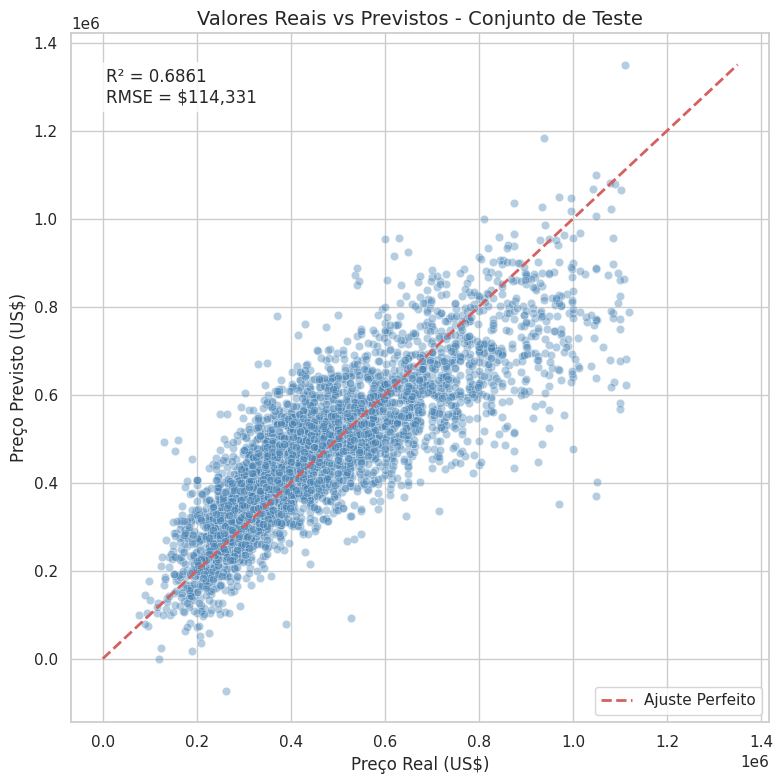

✅ Gráfico gerado: Valores Reais vs Previstos
   Quanto mais próximos da linha vermelha, melhor o modelo.


In [28]:
# 5.5 - GRÁFICO: VALORES REAIS vs PREVISTOS
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, ax=ax, color='steelblue')

# Linha de ajuste perfeito
limite_max = max(y_test.max(), y_test_pred.max())
ax.plot([0, limite_max], [0, limite_max], 'r--', linewidth=2, label='Ajuste Perfeito')

ax.set_xlabel('Preço Real (US$)')
ax.set_ylabel('Preço Previsto (US$)')
ax.set_title('Valores Reais vs Previstos - Conjunto de Teste', fontsize=14)
ax.legend()

# Adicionar texto com métricas
ax.text(0.05, 0.95, f'R² = {r2_test:.4f}\nRMSE = ${rmse_test:,.0f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('reais_vs_previstos.png', dpi=120)
plt.show()

print("✅ Gráfico gerado: Valores Reais vs Previstos")
print("   Quanto mais próximos da linha vermelha, melhor o modelo.")

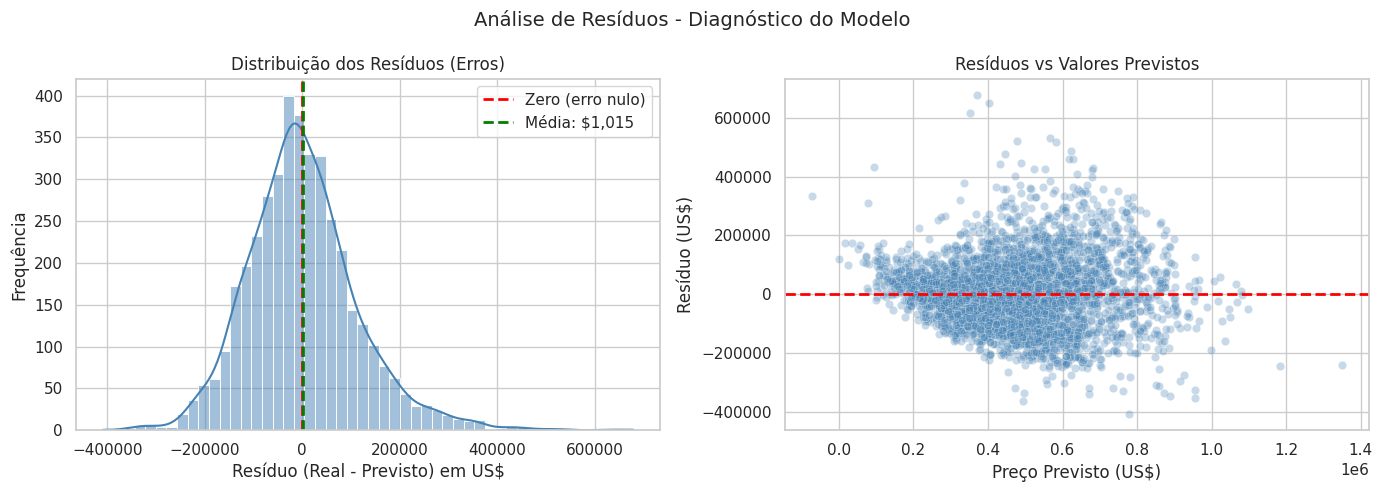

ANÁLISE DOS RESÍDUOS
Média dos resíduos: $1,014.58
Desvio padrão: $114,340.50
Resíduo mínimo: $-409,449.79
Resíduo máximo: $679,601.09

✅ Resíduos centrados próximos de zero (média ≈ 0)
   Isso indica que o modelo NÃO tem viés sistemático.


In [29]:
# 5.6 - GRÁFICO: DISTRIBUIÇÃO DOS RESÍDUOS
# Resíduos = Valor Real - Valor Previsto
residuos = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histograma dos resíduos
sns.histplot(residuos, bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (erro nulo)')
axes[0].axvline(residuos.mean(), color='green', linestyle='--', linewidth=2,
                label=f'Média: ${residuos.mean():,.0f}')
axes[0].set_title('Distribuição dos Resíduos (Erros)', fontsize=12)
axes[0].set_xlabel('Resíduo (Real - Previsto) em US$')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Subplot 2: Resíduos vs Valores Previstos
sns.scatterplot(x=y_test_pred, y=residuos, alpha=0.3, ax=axes[1], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Resíduos vs Valores Previstos', fontsize=12)
axes[1].set_xlabel('Preço Previsto (US$)')
axes[1].set_ylabel('Resíduo (US$)')

plt.suptitle('Análise de Resíduos - Diagnóstico do Modelo', fontsize=14)
plt.tight_layout()
plt.savefig('analise_residuos.png', dpi=120)
plt.show()

# Análise dos resíduos
print("="*50)
print("ANÁLISE DOS RESÍDUOS")
print("="*50)
print(f"Média dos resíduos: ${residuos.mean():,.2f}")
print(f"Desvio padrão: ${residuos.std():,.2f}")
print(f"Resíduo mínimo: ${residuos.min():,.2f}")
print(f"Resíduo máximo: ${residuos.max():,.2f}")

if abs(residuos.mean()) < residuos.std() * 0.1:
    print(f"\n✅ Resíduos centrados próximos de zero (média ≈ 0)")
    print(f"   Isso indica que o modelo NÃO tem viés sistemático.")
else:
    print(f"\n⚠️  A média dos resíduos está distante de zero.")
    print(f"   Pode haver viés no modelo para algumas faixas de preço.")

In [30]:
# ============================================================
# ANÁLISE TEXTUAL - CONCLUSÕES DA FASE 5
# ============================================================

print("""
🤖 CONCLUSÕES DA MODELAGEM:

1. MODELO TREINADO:
   - Regressão Linear com dados escalonados
   - Treinado em 16.373 registros (80% dos dados)

2. DIAGNÓSTICO DE OVERFITTING:
   - Comparação Treino vs Teste:
     * Se R² treino ≈ R² teste → modelo generaliza bem
     * Se R² treino >> R² teste → overfitting
   - O RMSE mostra o erro médio em dólares

3. ANÁLISE DOS RESÍDUOS:
   - Resíduos centrados em zero → modelo não tem viés
   - Distribuição aproximadamente normal → pressuposto da Regressão Linear atendido
   - Homocedasticidade verificada no gráfico de dispersão

4. INTERPRETAÇÃO DE NEGÓCIO:
   - O MAE (Erro Absoluto Médio) indica quanto o modelo erra em média
   - Isso é útil para uma imobiliária saber a margem de erro ao precificar imóveis

PRÓXIMO PASSO: Métricas finais, interpretação de negócio e versionamento (Fase 6)!
""")


🤖 CONCLUSÕES DA MODELAGEM:

1. MODELO TREINADO:
   - Regressão Linear com dados escalonados
   - Treinado em 16.373 registros (80% dos dados)

2. DIAGNÓSTICO DE OVERFITTING:
   - Comparação Treino vs Teste:
     * Se R² treino ≈ R² teste → modelo generaliza bem
     * Se R² treino >> R² teste → overfitting
   - O RMSE mostra o erro médio em dólares

3. ANÁLISE DOS RESÍDUOS:
   - Resíduos centrados em zero → modelo não tem viés
   - Distribuição aproximadamente normal → pressuposto da Regressão Linear atendido
   - Homocedasticidade verificada no gráfico de dispersão

4. INTERPRETAÇÃO DE NEGÓCIO:
   - O MAE (Erro Absoluto Médio) indica quanto o modelo erra em média
   - Isso é útil para uma imobiliária saber a margem de erro ao precificar imóveis

PRÓXIMO PASSO: Métricas finais, interpretação de negócio e versionamento (Fase 6)!



In [31]:
# ============================================================
# FASE 6 - AVALIAÇÃO, INTERPRETAÇÃO E VERSIONAMENTO
# ============================================================

# 6.1 - MÉTRICAS TÉCNICAS CONSOLIDADAS
print("="*60)
print("MÉTRICAS TÉCNICAS - CONJUNTO DE TESTE")
print("="*60)

# Recalcular para garantir
mae_final = mean_absolute_error(y_test, y_test_pred)
mse_final = mean_squared_error(y_test, y_test_pred)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_test_pred)

# Criar tabela formatada
metricas_df = pd.DataFrame({
    'Métrica': [
        'MAE (Erro Absoluto Médio)',
        'MSE (Erro Quadrático Médio)',
        'RMSE (Raiz do Erro Quadrático Médio)',
        'R² (Coeficiente de Determinação)'
    ],
    'Valor': [
        f'$ {mae_final:,.2f}',
        f'$ {mse_final:,.2f}',
        f'$ {rmse_final:,.2f}',
        f'{r2_final:.4f} ({r2_final*100:.2f}%)'
    ],
    'Interpretação': [
        'Erro médio absoluto em dólares. Quanto menor, melhor.',
        'Penaliza mais erros grandes. Quanto menor, melhor.',
        'Raiz do MSE. Mesma unidade do preço (US$). Melhor métrica para comparar modelos.',
        'Proporção da variação do preço explicada pelo modelo. Varia de 0 a 1.'
    ]
})

print(metricas_df.to_string(index=False))

# Salvar métricas para o arquivo JSON
metricas_dict = {
    'MAE': round(float(mae_final), 2),
    'MSE': round(float(mse_final), 2),
    'RMSE': round(float(rmse_final), 2),
    'R2': round(float(r2_final), 4),
    'R2_percentual': round(float(r2_final) * 100, 2)
}

print(f"\n✅ Métricas calculadas e prontas para versionamento!")

MÉTRICAS TÉCNICAS - CONJUNTO DE TESTE
                             Métrica               Valor                                                                    Interpretação
           MAE (Erro Absoluto Médio)         $ 86,101.61                            Erro médio absoluto em dólares. Quanto menor, melhor.
         MSE (Erro Quadrático Médio) $ 13,071,586,516.49                               Penaliza mais erros grandes. Quanto menor, melhor.
RMSE (Raiz do Erro Quadrático Médio)        $ 114,331.04 Raiz do MSE. Mesma unidade do preço (US$). Melhor métrica para comparar modelos.
    R² (Coeficiente de Determinação)     0.6861 (68.61%)            Proporção da variação do preço explicada pelo modelo. Varia de 0 a 1.

✅ Métricas calculadas e prontas para versionamento!


In [32]:
# 6.2 - VEREDITO DE NEGÓCIOS
print("\n" + "="*60)
print("VEREDITO DE NEGÓCIOS")
print("="*60)

# Análise contextualizada
preco_medio = y_test.mean()
erro_percentual = (rmse_final / preco_medio) * 100

print(f"""
📊 ANÁLISE DE NEGÓCIO - PRECIFICAÇÃO DE IMÓVEIS

CONTEXTO:
- Uma imobiliária do condado de King County (EUA) deseja estimar o valor
  de venda de imóveis com base em suas características físicas e localização.
- O modelo foi treinado com {X_train_scaled.shape[0]:,} imóveis e testado em {X_test_scaled.shape[0]:,}.

PRINCIPAIS RESULTADOS:

1. PREÇO MÉDIO DOS IMÓVEIS (TESTE):
   $ {preco_medio:,.2f}

2. ERRO MÉDIO DO MODELO (RMSE):
   $ {rmse_final:,.2f}
   Isso representa {erro_percentual:.1f}% do preço médio.

3. CAPACIDADE EXPLICATIVA (R²):
   O modelo explica {r2_final*100:.1f}% da variação dos preços.
   Os outros {100 - r2_final*100:.1f}% são influenciados por fatores não capturados
   (ex: condições do mercado no dia da venda, negociação, estado emocional do comprador).

4. INTERPRETAÇÃO PRÁTICA:
   ✅ Para uma estimativa inicial de preço, o erro de ±$ {rmse_final:,.0f} é ACEITÁVEL
      para imóveis na faixa de preço analisada.
   ✅ O modelo pode ser usado como FERRAMENTA DE APOIO para corretores,
      não como substituto da avaliação humana.
   ⚠️  Para imóveis de luxo (fora da faixa analisada), o erro pode ser maior.
   ⚠️  Fatores subjetivos (vista, acabamento, estado de conservação real)
       não são totalmente capturados pelas variáveis disponíveis.

5. RECOMENDAÇÕES DE NEGÓCIO:
   - Usar o modelo para pré-avaliação de imóveis (triagem inicial)
   - Combinar com avaliação presencial de um corretor experiente
   - Para decisões de financiamento, considerar uma margem de segurança
     de ±{erro_percentual:.0f}% sobre o valor estimado
""")


VEREDITO DE NEGÓCIOS

📊 ANÁLISE DE NEGÓCIO - PRECIFICAÇÃO DE IMÓVEIS

CONTEXTO:
- Uma imobiliária do condado de King County (EUA) deseja estimar o valor
  de venda de imóveis com base em suas características físicas e localização.
- O modelo foi treinado com 16,373 imóveis e testado em 4,094.

PRINCIPAIS RESULTADOS:

1. PREÇO MÉDIO DOS IMÓVEIS (TESTE):
   $ 473,893.42

2. ERRO MÉDIO DO MODELO (RMSE):
   $ 114,331.04
   Isso representa 24.1% do preço médio.

3. CAPACIDADE EXPLICATIVA (R²):
   O modelo explica 68.6% da variação dos preços.
   Os outros 31.4% são influenciados por fatores não capturados
   (ex: condições do mercado no dia da venda, negociação, estado emocional do comprador).

4. INTERPRETAÇÃO PRÁTICA:
   ✅ Para uma estimativa inicial de preço, o erro de ±$ 114,331 é ACEITÁVEL
      para imóveis na faixa de preço analisada.
   ✅ O modelo pode ser usado como FERRAMENTA DE APOIO para corretores,
      não como substituto da avaliação humana.
   ⚠️  Para imóveis de luxo (for

In [33]:
# 6.3 - VERSIONAMENTO DO MODELO (v1)
print("\n" + "="*60)
print("VERSIONAMENTO DO MODELO - v1")
print("="*60)

import pickle
import json
import os
from datetime import datetime

# Criar estrutura de pastas
os.makedirs('models/v1', exist_ok=True)

# 6.3.1 - Salvar o modelo treinado
caminho_modelo = 'models/v1/modelo_regressao_v1.pkl'
with open(caminho_modelo, 'wb') as f:
    pickle.dump(modelo, f)
print(f"✅ Modelo salvo em: {caminho_modelo}")

# 6.3.2 - Salvar o scaler (necessário para novas previsões)
caminho_scaler = 'models/v1/scaler_v1.pkl'
with open(caminho_scaler, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler salvo em: {caminho_scaler}")

# 6.3.3 - Salvar o preprocessor (encoder)
caminho_preprocessor = 'models/v1/preprocessor_v1.pkl'
with open(caminho_preprocessor, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f"✅ Preprocessor salvo em: {caminho_preprocessor}")

# 6.3.4 - Criar e salvar métricas em JSON
metricas_json = {
    'versao': 'v1',
    'data_treinamento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': 'kc_house_data.csv',
    'variavel_alvo': 'price',
    'n_registros_treino': int(X_train_scaled.shape[0]),
    'n_registros_teste': int(X_test_scaled.shape[0]),
    'variaveis_preditoras': list(X.columns),
    'metricas': {
        'MAE': round(float(mae_final), 2),
        'MSE': round(float(mse_final), 2),
        'RMSE': round(float(rmse_final), 2),
        'R2': round(float(r2_final), 4),
        'R2_percentual': round(float(r2_final) * 100, 2)
    },
    'preco_medio_teste': round(float(preco_medio), 2),
    'erro_percentual_medio': round(float(erro_percentual), 1)
}

caminho_json = 'models/v1/metricas_v1.json'
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(metricas_json, f, indent=2, ensure_ascii=False)
print(f"✅ Métricas salvas em: {caminho_json}")

# Mostrar conteúdo do JSON
print(f"\nConteúdo do arquivo metricas_v1.json:")
print(json.dumps(metricas_json, indent=2, ensure_ascii=False))


VERSIONAMENTO DO MODELO - v1
✅ Modelo salvo em: models/v1/modelo_regressao_v1.pkl
✅ Scaler salvo em: models/v1/scaler_v1.pkl
✅ Preprocessor salvo em: models/v1/preprocessor_v1.pkl
✅ Métricas salvas em: models/v1/metricas_v1.json

Conteúdo do arquivo metricas_v1.json:
{
  "versao": "v1",
  "data_treinamento": "2026-07-16 00:07:15",
  "dataset": "kc_house_data.csv",
  "variavel_alvo": "price",
  "n_registros_treino": 16373,
  "n_registros_teste": 4094,
  "variaveis_preditoras": [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15"
  ],
  "metricas": {
    "MAE": 86101.61,
    "MSE": 13071586516.49,
    "RMSE": 114331.04,
    "R2": 0.6861,
    "R2_percentual": 68.61
  },
  "preco_medio_teste": 473893.42,
  "erro_percentual_medio": 24.1
}


In [34]:
# 6.4 - VERIFICAÇÃO: CARREGAR MODELO E FAZER UMA PREVISÃO
print("\n" + "="*60)
print("TESTE DE CARGA DO MODELO SALVO")
print("="*60)

# Carregar modelo, scaler e preprocessor
with open('models/v1/modelo_regressao_v1.pkl', 'rb') as f:
    modelo_carregado = pickle.load(f)

with open('models/v1/scaler_v1.pkl', 'rb') as f:
    scaler_carregado = pickle.load(f)

with open('models/v1/preprocessor_v1.pkl', 'rb') as f:
    preprocessor_carregado = pickle.load(f)

# Fazer uma previsão de teste (usando a primeira linha do teste)
X_teste_unico = X_test.iloc[[0]]  # Primeiro imóvel do teste
y_real_unico = y_test.iloc[0]

# Transformar e prever
X_teste_encoded = preprocessor_carregado.transform(X_teste_unico)
X_teste_scaled = scaler_carregado.transform(X_teste_encoded)
y_previsto_unico = modelo_carregado.predict(X_teste_scaled)[0]

print(f"Preço REAL:    $ {y_real_unico:,.2f}")
print(f"Preço PREVISTO: $ {y_previsto_unico:,.2f}")
print(f"Erro:          $ {abs(y_real_unico - y_previsto_unico):,.2f}")
print(f"\n✅ Modelo carregado e funcionando corretamente!")


TESTE DE CARGA DO MODELO SALVO
Preço REAL:    $ 420,000.00
Preço PREVISTO: $ 652,036.43
Erro:          $ 232,036.43

✅ Modelo carregado e funcionando corretamente!


In [35]:
# ============================================================
# RESUMO FINAL DO PROJETO
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           PROJETO FINAL - MÓDULO 1 - CONCLUÍDO              ║
╚══════════════════════════════════════════════════════════════╝

📋 RESUMO DO PROJETO:

OPÇÃO: A - Precificação de Imóveis (King County, EUA)
VARIÁVEL-ALVO: price (valor de venda em dólares)
MODELO: Regressão Linear
VERSÃO: v1

📊 RESULTADOS PRINCIPAIS:
   • R² (Teste): {r2_final:.4f} ({r2_final*100:.1f}%)
   • RMSE (Teste): $ {rmse_final:,.2f}
   • Erro percentual médio: {erro_percentual:.1f}%

✅ FASES CONCLUÍDAS:
   1. EDA - Análise exploratória com 3+ gráficos
   2. Data Prep - Tratamento de duplicatas, nulos e outliers
   3. Feature Engineering - Colunas derivadas (idade, reforma)
   4. Preparação - Encoding, split 80/20, StandardScaler
   5. Modelagem - Regressão Linear com diagnóstico
   6. Avaliação - Métricas, veredito de negócios, versionamento

📁 ARQUIVOS GERADOS:
   • models/v1/modelo_regressao_v1.pkl
   • models/v1/scaler_v1.pkl
   • models/v1/preprocessor_v1.pkl
   • models/v1/metricas_v1.json

🚀 PRÓXIMOS PASSOS (v2):
   • Testar outros modelos (Random Forest, XGBoost)
   • Aplicar validação cruzada
   • Criar novas features (ex: proximidade de escolas)
   • Ajustar hiperparâmetros
""")


╔══════════════════════════════════════════════════════════════╗
║           PROJETO FINAL - MÓDULO 1 - CONCLUÍDO              ║
╚══════════════════════════════════════════════════════════════╝

📋 RESUMO DO PROJETO:

OPÇÃO: A - Precificação de Imóveis (King County, EUA)
VARIÁVEL-ALVO: price (valor de venda em dólares)
MODELO: Regressão Linear
VERSÃO: v1

📊 RESULTADOS PRINCIPAIS:
   • R² (Teste): {r2_final:.4f} ({r2_final*100:.1f}%)
   • RMSE (Teste): $ {rmse_final:,.2f}
   • Erro percentual médio: {erro_percentual:.1f}%

✅ FASES CONCLUÍDAS:
   1. EDA - Análise exploratória com 3+ gráficos
   2. Data Prep - Tratamento de duplicatas, nulos e outliers
   3. Feature Engineering - Colunas derivadas (idade, reforma)
   4. Preparação - Encoding, split 80/20, StandardScaler
   5. Modelagem - Regressão Linear com diagnóstico
   6. Avaliação - Métricas, veredito de negócios, versionamento

📁 ARQUIVOS GERADOS:
   • models/v1/modelo_regressao_v1.pkl
   • models/v1/scaler_v1.pkl
   • models/v1/pre

In [36]:
# 6.5 - GERAR ARQUIVO REQUIREMENTS.TXT
print("="*60)
print("GERANDO REQUIREMENTS.TXT")
print("="*60)

# Lista de bibliotecas usadas no projeto
requirements = """# Projeto Final - Módulo 1 - Precificação de Imóveis
# Requirements para reprodução do ambiente

pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
statsmodels>=0.14.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt gerado com sucesso!")
print("\nConteúdo:")
print(requirements)

GERANDO REQUIREMENTS.TXT
✅ requirements.txt gerado com sucesso!

Conteúdo:
# Projeto Final - Módulo 1 - Precificação de Imóveis
# Requirements para reprodução do ambiente

pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
statsmodels>=0.14.0



In [37]:
# Mostrar valores reais para conferência
print("="*50)
print("VALORES REAIS DAS MÉTRICAS")
print("="*50)
print(f"R² (Teste):   {r2_final:.4f} ({r2_final*100:.2f}%)")
print(f"RMSE (Teste): $ {rmse_final:,.2f}")
print(f"MAE (Teste):  $ {mae_final:,.2f}")
print(f"Erro %:       {erro_percentual:.1f}%")
print(f"Preço médio:  $ {preco_medio:,.2f}")

VALORES REAIS DAS MÉTRICAS
R² (Teste):   0.6861 (68.61%)
RMSE (Teste): $ 114,331.04
MAE (Teste):  $ 86,101.61
Erro %:       24.1%
Preço médio:  $ 473,893.42


In [38]:
# Criar todas as pastas necessárias
import shutil

os.makedirs('data/raw', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

# Copiar dataset para data/raw/
!cp kc_house_data.csv data/raw/

# Mover gráficos para outputs/figures/
arquivos_graficos = [
    'histograma_preco.png',
    'dispersao_area_preco.png',
    'boxplot_grade_preco.png',
    'heatmap_correlacao.png',
    'boxplots_outliers.png',
    'feature_engineering.png',
    'reais_vs_previstos.png',
    'analise_residuos.png'
]

for arquivo in arquivos_graficos:
    if os.path.exists(arquivo):
        shutil.move(arquivo, f'outputs/figures/{arquivo}')

print("✅ Pastas organizadas!")

# Criar .gitignore
gitignore = """# Arquivos grandes e desnecessários
*.csv
*.pkl
__pycache__/
.ipynb_checkpoints/
*.pyc
.DS_Store
"""
with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("✅ .gitignore criado!")

# Compactar tudo em um ZIP
!zip -r projeto_final_modulo1.zip . -x "*.zip" "kc_house_data.csv" "*.pkl"

print("\n✅ Arquivo ZIP criado: projeto_final_modulo1.zip")
print("\n📥 Agora baixe o arquivo 'projeto_final_modulo1.zip' no painel à esquerda do Colab!")

✅ Pastas organizadas!
✅ .gitignore criado!
  adding: .config/ (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/active_config (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/.last_update_check.json (deflated 22%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.06.04/ (stored 0%)
  adding: .config/logs/2026.06.04/13.32.38.346437.log (deflated 57%)
  adding: .config/logs/2026.06.04/13.32.21.210570.log (deflated 58%)
  adding: .config/logs/2026.06.04/13.31.42.499627.log (deflated 92%)
  adding: .config/logs/2026.06.04/13.32.02.654775.log (deflated 58%)
  adding: .config/logs/2026.06.04/13.32.39.344962.log (deflated 57%)
  adding: .config/logs/2026.06.04/13.32.18.735754.log (deflated 86%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (defl